# Platform Self Noise

In [1]:
import numpy as np
from scipy.signal import get_window
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
    KnownTurnRate,
)
from stonesoup.types.groundtruth import GroundTruthState, GroundTruthPath

from nereus.platform import TowedArrayPlatform
from nereus.models.environment import Linear, FlatBathymetry
from nereus.models.propagation import rtrsAcousticPropagationModel
from nereus.signal.anthropogenic import BroadbandShipSignal
from nereus.signal.ambient import ColouredNoise
from nereus.simulator import BroadbandPassiveSonarArraySimulator
from nereus.sigproc import DelayAndSumBeamformer, SteeringCalculator, MinimumVarianceDistortionlessResponseBeamformer
from nereus.detector import CACFARDetector, PassiveSonarDetector, PeakDetector
from nereus.plotter import BearingsPlotter

seed = 12
print(f"seed: {seed}")
np.random.seed(seed)

def random_start_vector(X, Vx, Y, Vy):
    return np.array([
        np.random.uniform(X[0], X[1]),
        np.random.uniform(Vx[0], Vx[1]),
        np.random.uniform(Y[0], Y[1]),
        np.random.uniform(Vy[0], Vy[1]),
        -5,
        0,
    ])

def generate_random_maneuvers(total_duration_s, timestep_s, min_leg_duration_s=60, max_leg_duration_s=300, maneuver_prob=0.5):
    """Generate random sequence of straight/turn maneuvers. manoeuvrers
    
    Args:
        total_duration_s: Total simulation time in seconds
        timestep_s: Simulation timestep in seconds
        min_leg_duration_s: Minimum duration for each leg
        max_leg_duration_s: Maximum duration for each leg
        maneuver_prob: Probability of performing a turn maneuver at each leg
    
    Returns:
        maneuver_models: List of transition models (3D)
        maneuver_durations: List of timedelta durations for each leg
        maneuver_descriptions: List of string descriptions for logging
    """
    maneuver_models = []
    maneuver_durations = []
    maneuver_descriptions = []
    
    current_time = 0.0
    
    while current_time < total_duration_s - min_leg_duration_s:
        # Random leg duration (round to nearest timestep)
        leg_duration = np.random.uniform(min_leg_duration_s, max_leg_duration_s)
        leg_duration = round(leg_duration / timestep_s) * timestep_s
        leg_duration = min(leg_duration, total_duration_s - current_time)
        
        # Decide maneuver
        if np.random.rand() > maneuver_prob:
            # Straight leg
            model = CombinedLinearGaussianTransitionModel([
                ConstantVelocity(0.0), 
                ConstantVelocity(0.0), 
                ConstantVelocity(0.0)
            ])
            description = f"Straight ({leg_duration:.0f}s)"
        else:
            # Random turn: -90° to +90° (negative = right turn, positive = left turn)
            turn_angle_deg = np.random.uniform(-90, 90)
            turn_rate_deg_per_s = 1.0  # Standard turn rate
            
            # Calculate actual turn duration based on angle
            turn_duration_s = abs(turn_angle_deg) / turn_rate_deg_per_s
            turn_duration_s = round(turn_duration_s / timestep_s) * timestep_s
            leg_duration = min(turn_duration_s, total_duration_s - current_time)
            
            turn_rate_rad = np.deg2rad(np.sign(turn_angle_deg) * turn_rate_deg_per_s)
            
            turning_2d = KnownTurnRate(
                turn_rate=turn_rate_rad,
                turn_noise_diff_coeffs=np.array([0.0, 0.0])
            )
            
            model = CombinedLinearGaussianTransitionModel([
                turning_2d,
                ConstantVelocity(0.0)  # Constant depth
            ])
            
            direction = "Left" if turn_angle_deg > 0 else "Right"
            description = f"{direction} Turn {abs(turn_angle_deg):.0f}° ({leg_duration:.0f}s)"
        
        maneuver_models.append(model)
        maneuver_durations.append(timedelta(seconds=leg_duration))
        maneuver_descriptions.append(description)
        
        current_time += leg_duration
    
    return maneuver_models, maneuver_durations, maneuver_descriptions



ImportError: cannot import name 'CACACFARDetector' from 'nereus.detector.algorithms' (/home/fin/Documents/python/nereus/nereus/detector/algorithms.py)

# SIMULATION PARAMETERS

Longer tow cable lengths help reduce effects of platform self noise.

In [ ]:
SIM_LENGTH = 900 # seconds
SIM_RATE = 5.0 # seconds

Xlim = [-15_000, 15_000]
Ylim = [-15_000, 15_000]

NUM_TARGETS = 3

SIM_PARAMS = {
    "start_time":datetime.now().replace(hour=0, minute=0, second=0, microsecond=0),
    "time_interval":timedelta(seconds=SIM_RATE),
    "num_steps":int(SIM_LENGTH / SIM_RATE),
}

total_duration_s = SIM_PARAMS["num_steps"] * SIM_PARAMS["time_interval"].total_seconds()
print(f"Total simulation duration: {total_duration_s} seconds")
print(f"Number of timesteps: {SIM_PARAMS['num_steps']}, Timestep interval: {SIM_PARAMS['time_interval'].total_seconds()} seconds")

SHIP_PARAMS = {
    "start_vector": random_start_vector(Xlim, [-4,4], Ylim, [-4, 4]), 
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
    "amplitudes_upa": 10 ** (np.array([80.0, 77.0, 81.0, 76.0]) / 20),
    "frequencies_hz": np.array([50.0, 100.0, 130.0, 200.0]),
    "phases_rad": np.array([0.0, 0.0, 0.0, 0.0]),
    "tonal_bandwidth_hz": 1.0,
    "noise_amplitude_upa":10 ** (74.0 / 20),
    "noise_spectral_exponent":-1.0,
}

ARRAY_PARAMS = {
    "num_sensors": 200,  
    "tow_cable_length": 400.0,
    "sensor_spacing": 0.5,
    "array_depth": -50.0,
}

TARGETS = []

for i in range(NUM_TARGETS):
    TARGET_PARAMS = {
        "start_vector": random_start_vector(Xlim, [-10.5,10.5], Ylim, [-10.5, 10.5]),  
        "position_mapping": [0, 2, 4],
        "velocity_mapping": [1, 3, 5],
        "transition_model": CombinedLinearGaussianTransitionModel(
            [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
        ),
        "amplitudes_upa": 10 ** (np.random.uniform(87, 102, 4) / 20),
        "frequencies_hz": np.random.uniform(25.0, 200.0, 4),
        "phases_rad": np.random.uniform(0, 2 * np.pi, 4),
        "tonal_bandwidth_hz": np.random.uniform(0.5, 2.0),
        "noise_amplitude_upa":10 ** (np.random.uniform(65, 85) / 20),
        "noise_spectral_exponent":-1.0,
    }
    TARGETS.append(TARGET_PARAMS)

SIGNAL_PARAMS = {
    "duration_s": total_duration_s,
    "sampling_rate_hz": 500.0, 
    "frame_len": 500,
    "hop_factor": 2,
    "fade_in_ms": 1000.0,
}

AMBIENT_NOISE_PARAMS = {
    "amplitude_upa": 10 ** (np.random.uniform(45, 55) / 20),  
    "spectral_exponent": -1,  
}

PROP_PARAMS = {
    "ssp": Linear(surface_speed=1500.0, gradient=0.2),
    "attenuation_factor": 0.5, 
    "bathymetry": FlatBathymetry(depth=-150.0),
    "step_m": 20.0,
    "azimuth_search_width": 2.0,
    "azimuth_resolution": 0.5,
    "elevation_range": (-25.0, 25.0),
    "elevation_resolution": 1.0,
}

BF_PARAMS = {
    "beamformer_type": "DAS",
    "shading": None,
    # "shading": "blackman",
    "domain": "frequency",
    "steering_azimuths_rad": np.linspace(-np.pi, np.pi, 361), 
}

# Detection parameters
DET_PARAMS = {
    "cfar_detector": {
        "num_guard_cells": 2,
        "num_training_cells": 5,
        "threshold_factor": 1.05,  
    },
    "peak_detector": {
        "distance": 3,  
    }
}

Total simulation duration: 900.0 seconds
Number of timesteps: 180, Timestep interval: 5.0 seconds


# SETUP

## Platform setup with self noise

In [ ]:
# Generate random maneuvers for platform
maneuver_models, maneuver_durations, maneuver_descriptions = generate_random_maneuvers(
    total_duration_s=total_duration_s,
    timestep_s=SIM_PARAMS["time_interval"].total_seconds(),
    min_leg_duration_s=60,
    max_leg_duration_s=300,  
    maneuver_prob=0.15
)

# Create platform
initial_state = GroundTruthState(
    SHIP_PARAMS["start_vector"], timestamp=SIM_PARAMS["start_time"]
)
platform = TowedArrayPlatform(
    states=[initial_state],
    position_mapping=SHIP_PARAMS["position_mapping"],
    velocity_mapping=SHIP_PARAMS["velocity_mapping"],
    transition_models=maneuver_models,
    transition_times=maneuver_durations,
    num_sensors=ARRAY_PARAMS["num_sensors"],
    cable_length_m=ARRAY_PARAMS["tow_cable_length"],
    sensor_spacing_m=ARRAY_PARAMS["sensor_spacing"],
    array_depth_m=ARRAY_PARAMS["array_depth"],
)

# Move platform through all timesteps
for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    platform.move(new_time)

# create gt for platform self noise
self_noise_states = [
    GroundTruthState(
        state.state_vector,
        timestamp=state.timestamp,
        metadata={
            "position_mapping": SHIP_PARAMS["position_mapping"],
            "velocity_mapping": SHIP_PARAMS["velocity_mapping"],
            "amplitudes_upa": SHIP_PARAMS["amplitudes_upa"],
            "frequencies_hz": SHIP_PARAMS["frequencies_hz"],
            "phases_rad": SHIP_PARAMS["phases_rad"],
            "tonal_bandwidth_hz": SHIP_PARAMS["tonal_bandwidth_hz"],
            "noise_amplitude_upa": SHIP_PARAMS["noise_amplitude_upa"],
            "noise_spectral_exponent": SHIP_PARAMS["noise_spectral_exponent"],
        },
    )
    for state in platform.movement_controller.states
]
self_noise_ground_truth = GroundTruthPath(self_noise_states)

## Target Setup

In [ ]:
# Create target trajectories
target_ground_truths = []
relative_bearing_ground_truths = []

for target_idx, TARGET_PARAMS in enumerate(TARGETS):

    # Create initial state
    target_states = [
        GroundTruthState(
            TARGET_PARAMS["start_vector"],
            timestamp=SIM_PARAMS["start_time"],
            metadata={
                "amplitudes_upa": TARGET_PARAMS["amplitudes_upa"],
                "frequencies_hz": TARGET_PARAMS["frequencies_hz"],
                "phases_rad": TARGET_PARAMS["phases_rad"],
                "position_mapping": TARGET_PARAMS["position_mapping"],
                "velocity_mapping": TARGET_PARAMS["velocity_mapping"],
                "tonal_bandwidth_hz": TARGET_PARAMS["tonal_bandwidth_hz"],
                "noise_amplitude_upa": TARGET_PARAMS["noise_amplitude_upa"],
                "noise_spectral_exponent": TARGET_PARAMS["noise_spectral_exponent"],
            },
        )
    ]

    # Propagate trajectory with multi-transition models
    current_maneuver_idx = 0
    
    for i in range(1, SIM_PARAMS["num_steps"]):

        transition_model = TARGET_PARAMS["transition_model"]
        new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        time_interval = new_time - target_states[-1].timestamp
        new_state_vector = transition_model.function(
            target_states[-1], noise=False, time_interval=time_interval
        )
        new_state = GroundTruthState(
            new_state_vector,
            timestamp=new_time,
            metadata=target_states[-1].metadata,
        )
        target_states.append(new_state)

    target_ground_truth = GroundTruthPath(target_states)
    target_ground_truths.append(target_ground_truth)
    
    # Compute ground truth bearings for plotting
    gt_relative_bearings = []
    for target_state in target_ground_truth.states:
        platform_state = platform.get_platform_state_at(target_state.timestamp)
        ref_sensor_position = np.mean(platform_state.array.state_vector, axis=1)
        target_pos = np.array([target_state.state_vector[0], target_state.state_vector[2]])
        relative_pos = target_pos - ref_sensor_position[:2]
        bearing_rad = np.arctan2(relative_pos[1], relative_pos[0])
        gt_relative_bearings.append(bearing_rad)
    
    gt_relative_bearings = np.array(gt_relative_bearings)
    
    # Create GroundTruthPath for bearings
    relative_bearing_truth_states = []
    for i, bearing in enumerate(gt_relative_bearings):
        timestamp = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        bearing_state = GroundTruthState(
            state_vector=np.array([bearing]),
            timestamp=timestamp
        )
        relative_bearing_truth_states.append(bearing_state)
    
    relative_bearing_ground_truth = GroundTruthPath(relative_bearing_truth_states)
    relative_bearing_ground_truths.append(relative_bearing_ground_truth)

## Signal and propagation setup

In [ ]:
prop_model = rtrsAcousticPropagationModel(
    ssp=PROP_PARAMS["ssp"],
    bathymetry=PROP_PARAMS["bathymetry"],
    use_all_frequencies=False,  # Will use propagate_spectrum
    step_m=20.0,
    azimuth_search_width=2.0,
    azimuth_resolution=0.5,
    elevation_range=(-25.0, 25.0),
    elevation_resolution=1.0,
)

# Create ambient noise model
ambient_noise_model = ColouredNoise(
    amplitude_upa=AMBIENT_NOISE_PARAMS["amplitude_upa"],
    spectral_exponent=AMBIENT_NOISE_PARAMS["spectral_exponent"],
    duration_s=SIM_PARAMS["time_interval"].total_seconds(),
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
)

# Create signal models for each target
print("Creating signal models for each target...")
signal_models = []
for target_idx, TARGET_PARAMS in enumerate(TARGETS):
    signal_model = BroadbandShipSignal(
        duration_s=SIGNAL_PARAMS["duration_s"],
        sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
        frame_len=SIGNAL_PARAMS["frame_len"],
        hop_factor=SIGNAL_PARAMS["hop_factor"],
        tonal_bandwidth_hz=TARGET_PARAMS["tonal_bandwidth_hz"],
        noise_amplitude_upa=TARGET_PARAMS["noise_amplitude_upa"],
        noise_spectral_exponent=TARGET_PARAMS["noise_spectral_exponent"],
        noise_freq_range_hz=(0.0, SIGNAL_PARAMS["sampling_rate_hz"]/2),
        tonal_noise_is_constant=True,
        noise_is_constant=True,
    )
    signal_models.append(signal_model)

# Create signal model for platform self noise
self_noise_signal_model = BroadbandShipSignal(
    duration_s=SIGNAL_PARAMS["duration_s"],
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
    frame_len=SIGNAL_PARAMS["frame_len"],
    hop_factor=SIGNAL_PARAMS["hop_factor"],
    tonal_bandwidth_hz=SHIP_PARAMS["tonal_bandwidth_hz"],
    noise_amplitude_upa=SHIP_PARAMS["noise_amplitude_upa"],
    noise_spectral_exponent=SHIP_PARAMS["noise_spectral_exponent"],
    noise_freq_range_hz=(0.0, SIGNAL_PARAMS["sampling_rate_hz"] / 2),
    tonal_noise_is_constant=True,
    noise_is_constant=True,
)

Creating signal models for each target...


## Beamformer setup

In [ ]:

shading = None
if BF_PARAMS["shading"] is not None:
    shading = get_window(BF_PARAMS["shading"], platform.num_sensors)

if BF_PARAMS["beamformer_type"] == "DAS":
    if BF_PARAMS["domain"] == "broadband_power":
        beamformer = DelayAndSumBeamformer(
            domain=BF_PARAMS["domain"],
            sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
            fmin=BF_PARAMS["fmin"],
            fmax=BF_PARAMS["fmax"],
        )
    else:
        beamformer = DelayAndSumBeamformer(
            sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
            shading=shading,
            domain=BF_PARAMS["domain"]
        )
elif BF_PARAMS["beamformer_type"] == "MVDR":

    beamformer = MinimumVarianceDistortionlessResponseBeamformer(
        sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
        fmin=BF_PARAMS["fmin"],
        fmax=BF_PARAMS["fmax"],
    )
else:
    raise ValueError(f"Unknown beamformer type: {BF_PARAMS['beamformer_type']}")

steering_calculator = SteeringCalculator(
    ssp=PROP_PARAMS["ssp"],
    steering_azimuths_rad=BF_PARAMS["steering_azimuths_rad"],
)


## Simulator Setup

In [ ]:
# Create simulator; append self noise signal model and ground truth to lists
simulator = BroadbandPassiveSonarArraySimulator(
    platform=platform,
    propagation_model=prop_model,
    signal_models=signal_models + [self_noise_signal_model],
    noise_model=ambient_noise_model,
    beamformer=beamformer,
    steering_calculator=steering_calculator,
    ground_truth_paths=target_ground_truths + [self_noise_ground_truth],
    fade_in_ms=SIGNAL_PARAMS["fade_in_ms"],
)

## Detector Setup

In [ ]:
data_generator = simulator.sensor_data_gen()

# Create detection chain
cfar_detector = CACFARDetector(
    num_guard_cells=DET_PARAMS["cfar_detector"]["num_guard_cells"],
    num_training_cells=DET_PARAMS["cfar_detector"]["num_training_cells"],
    threshold_factor=DET_PARAMS["cfar_detector"]["threshold_factor"],
)
peak_detector = PeakDetector(distance=DET_PARAMS["peak_detector"]["distance"])

detection_chain = [cfar_detector]
detection_chain.append(peak_detector)

detector = PassiveSonarDetector(
    detection_chain=detection_chain,
    sensor_data_gen=data_generator,
    steering_azimuths_rad=BF_PARAMS["steering_azimuths_rad"]
)

# Run Simulation

In [ ]:
all_detections = list(detector.detections_gen(progress_bar=True))
snr_map = detector.snr_history

Generating Detections: 180it [01:50,  1.63it/s]


# VISUALIZATION

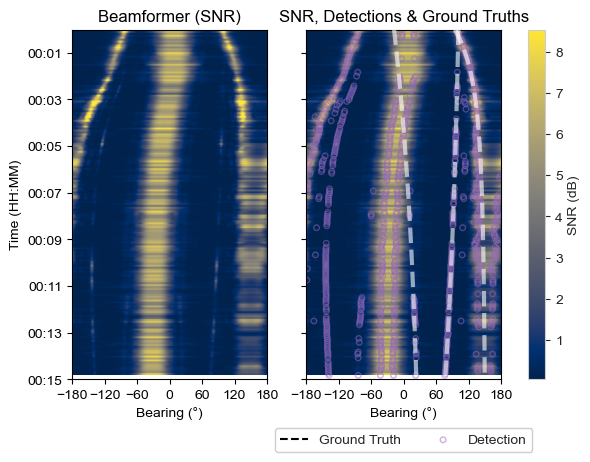

In [ ]:
timesteps = [
    SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    for i in range(SIM_PARAMS["num_steps"])
]

detections_for_plotter = [detection_set for _, detection_set in all_detections]

# Plot 1: Beamformer output with detections
fig1, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

style_guide = {
    "figure": {
        "figsize": (4, 4),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

# Left: Raw SNR (exclude last timestep)
plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=[],
    truths=[],
    ax=axs[0],
    add_colorbar=False
)
axs[0].set_title("Beamformer (SNR)")

# Right: SNR with detections and truth (exclude last timestep)
_, im = plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=detections_for_plotter[:-1],
    truths=relative_bearing_ground_truths,
    ax=axs[1],
    add_colorbar=False
)
axs[1].set_ylabel("")
axs[1].set_title(f"SNR, Detections & Ground Truths")

# Add shared colorbar
fig1.colorbar(im, ax=axs.tolist(), label='SNR (dB)')

/tmp/ipykernel_78029/1003732623.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


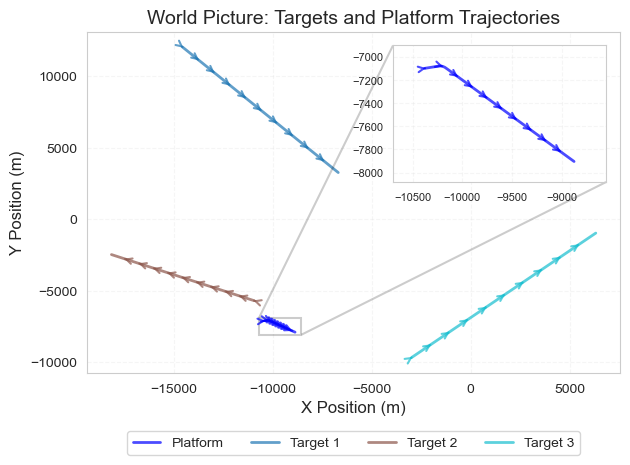

In [ ]:
fig2, ax_path = plt.subplots()

# Extract platform positions
platform_x = []
platform_y = []
array_x = []
array_y = []

for timestamp in timesteps:
    platform_state = platform.get_platform_state_at(timestamp)
    platform_x.append(platform_state.host.state.state_vector[0])
    platform_y.append(platform_state.host.state.state_vector[2])
    
    array_center = np.mean(platform_state.array.state_vector, axis=1)
    array_x.append(array_center[0])
    array_y.append(array_center[1])

# Plot platform trajectory with direction arrows
ax_path.plot(platform_x, platform_y, 'b-', label='Platform', linewidth=2, alpha=0.7)
# ax_path.plot(array_x, array_y, 'g--', label='Array Center', linewidth=1.5, alpha=0.6)

# Add direction arrows for platform (every 10th point to avoid clutter)
arrow_interval = max(1, len(platform_x) // 10)
for i in range(0, len(platform_x) - 1, arrow_interval):
    dx = platform_x[i + 1] - platform_x[i]
    dy = platform_y[i + 1] - platform_y[i]
    ax_path.annotate('', xy=(platform_x[i + 1], platform_y[i + 1]), 
                    xytext=(platform_x[i], platform_y[i]),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, alpha=0.7))

# Plot target trajectories with different colors
colors = plt.cm.tab10(np.linspace(0, 1, NUM_TARGETS))

for target_idx, target_ground_truth in enumerate(target_ground_truths):
    target_x = [state.state_vector[0] for state in target_ground_truth]
    target_y = [state.state_vector[2] for state in target_ground_truth]
    
    color = colors[target_idx]
    ax_path.plot(target_x, target_y, '-', color=color, 
                label=f'Target {target_idx + 1}', linewidth=2, alpha=0.7)
    
    # Add direction arrows for each target (every 10th point)
    for i in range(0, len(target_x) - 1, arrow_interval):
        dx = target_x[i + 1] - target_x[i]
        dy = target_y[i + 1] - target_y[i]
        ax_path.annotate('', xy=(target_x[i + 1], target_y[i + 1]), 
                        xytext=(target_x[i], target_y[i]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.7))
    

ax_path.set_xlabel('X Position (m)', fontsize=12)
ax_path.set_ylabel('Y Position (m)', fontsize=12)
ax_path.set_title(f'World Picture: Targets and Platform Trajectories', fontsize=14)
ax_path.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=4)
ax_path.grid(True, alpha=0.3)
# ax_path.axis('equal')

# Create inset zoom of platform trajectory
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
ax_inset = inset_axes(ax_path, width="40%", height="40%", loc='upper right', 
                      borderpad=1.)

# Determine zoom region (all of platform trajectory)
mid_idx = len(platform_x) // 2
zoom_range = len(platform_x) 
zoom_start = max(0, mid_idx - zoom_range)
zoom_end = min(len(platform_x), mid_idx + zoom_range)

# Get bounds of zoom region
x_zoom = platform_x[zoom_start:zoom_end]
y_zoom = platform_y[zoom_start:zoom_end]
x_min, x_max = min(x_zoom), max(x_zoom)
y_min, y_max = min(y_zoom), max(y_zoom)

# --- add padding so arrows fit inside ---
pad_x = 0.15 * (x_max - x_min)
pad_y = 0.15 * (y_max - y_min)

x_min -= pad_x
x_max += pad_x
y_min -= pad_y
y_max += pad_y

# Add rectangle to show zoom region on main plot
from matplotlib.patches import Rectangle
zoom_box = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                     fill=False, edgecolor='Black', linewidth=1.5, 
                     linestyle='-', alpha=0.4)
# ax_path.add_patch(zoom_box)

# Plot zoomed platform trajectory
ax_inset.plot(platform_x[zoom_start:zoom_end], platform_y[zoom_start:zoom_end], 
              'b-', linewidth=2, alpha=0.7)

# Add direction arrows in inset
inset_arrow_interval = max(1, (zoom_end - zoom_start) // 10)
for i in range(zoom_start, zoom_end - 1, inset_arrow_interval):
    dx = platform_x[i + 1] - platform_x[i]
    dy = platform_y[i + 1] - platform_y[i]
    ax_inset.annotate('', xy=(platform_x[i + 1], platform_y[i + 1]), 
                     xytext=(platform_x[i], platform_y[i]),
                     arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, alpha=0.7))

ax_inset.grid(True, alpha=0.3)
ax_inset.tick_params(labelsize=8)
# ax_inset.set_aspect('equal')

# ax_inset.plot(array_x, array_y, 'g--', label='Array Center', linewidth=1.5, alpha=0.6)
# Expand inset limits slightly so arrows fit inside the mark_inset box
x_pad = 0.05 * (x_max - x_min)
y_pad = 0.05 * (y_max - y_min)

ax_inset.set_xlim(x_min - x_pad, x_max + x_pad)
ax_inset.set_ylim(y_min - y_pad, y_max + y_pad)

# Connect inset to zoom box with diagonal lines
mark_inset(
    ax_path,
    ax_inset,
    loc1=2,   # upper left corner of box
    loc2=4,   # lower right corner of box
    fc="none",
    ec="black",
    lw=1.5,
    alpha=0.2,
)

plt.tight_layout()

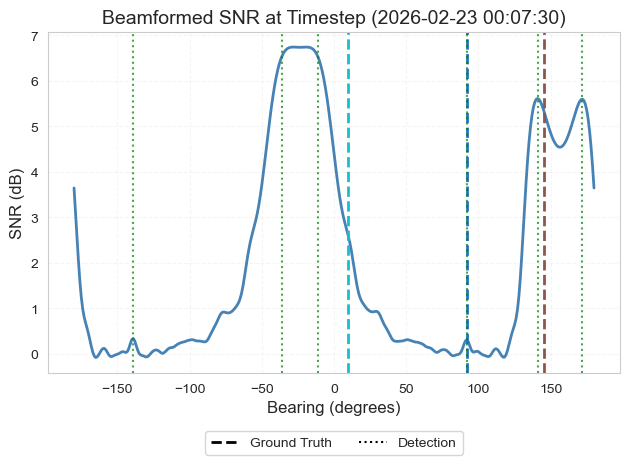

In [ ]:
fig3, ax_middle = plt.subplots()

middle_timestep_idx = SIM_PARAMS["num_steps"] // 2
middle_snr = snr_map[middle_timestep_idx, :]
middle_time = timesteps[middle_timestep_idx]

steering_azimuths_deg = np.rad2deg(BF_PARAMS["steering_azimuths_rad"])
ax_middle.plot(steering_azimuths_deg, middle_snr, linewidth=2, color='steelblue')
ax_middle.set_xlabel('Bearing (degrees)', fontsize=12)
ax_middle.set_ylabel('SNR (dB)', fontsize=12)
ax_middle.set_title(f'Beamformed SNR at Timestep ({middle_time})', fontsize=14)
ax_middle.grid(True, alpha=0.3)

# Mark ground truth bearings for all targets
for target_idx, gt_relative_bearings in enumerate([
    [state.state_vector[0] for state in gt_path.states] 
    for gt_path in relative_bearing_ground_truths
]):
    gt_bearing_deg = np.rad2deg(gt_relative_bearings[middle_timestep_idx])
    color = colors[target_idx]
    ax_middle.axvline(gt_bearing_deg, color=color, linestyle='--', linewidth=2, 
                     label=f'Target {target_idx + 1} GT ({gt_bearing_deg:.1f}°)')

# Mark detections at this timestep if any
if len(detections_for_plotter[middle_timestep_idx]) > 0:
    for det_idx, det in enumerate(detections_for_plotter[middle_timestep_idx]):
        det_bearing_deg = np.rad2deg(det.state_vector[0])
        label = 'Detections' if det_idx == 0 else None
        ax_middle.axvline(det_bearing_deg, color='green', linestyle=':', linewidth=1.5, 
                        label=label, alpha=0.7)

# Create custom legend handles
from matplotlib.lines import Line2D
custom_handles = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Ground Truth'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=1.5, label='Detection')
]
ax_middle.legend(handles=custom_handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=2)
plt.tight_layout()